# Chapter 3 — Full Experimental Pipeline: Credit Card Fraud Detection (main dataset)

**Extended version** — covers RQ1 (algorithms), RQ3 (imbalance handling), and RQ4
(latency/training time), with the full set of diagnostics expected in a Results
chapter: repeated runs for stability, ROC/PR curves, feature importance,
threshold analysis, and per-model confusion matrices.

**Dataset:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

**Runtime note:** with `N_RUNS = 3` (repeated seeds for robustness) on the full
284K-row dataset, SMOTE/ADASYN + Random Forest are the slowest steps. Expect this
to take noticeably longer than the light version. If you're short on time, set
`N_RUNS = 3            # set to 1 if you are tight on time` in the config cell below — the pipeline still runs, you just lose
the mean ± std robustness check.


## 0. Setup

In [ ]:
# !pip install scikit-learn xgboost imbalanced-learn matplotlib seaborn joblib -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, classification_report,
)
from imblearn.over_sampling import SMOTE, ADASYN
import xgboost as xgb

sns.set_theme(style="whitegrid")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0.1 Config — data path, output folders, robustness setting

`N_RUNS` controls how many random seeds each model/strategy combination is
trained with. More runs = more reliable mean ± std, but longer runtime.

In [ ]:
# --- Colab Drive mount ---
from google.colab import drive
drive.mount('/content/drive')

BASE = Path('/content/drive/MyDrive/Bicocca/Thesis code')
DATA_RAW = BASE / 'data' / 'raw'
DATA_PATH = DATA_RAW / 'creditcard.csv'   # <-- rename here if your file has a different name

OUTDIR = BASE / 'results' / 'credit_card'
FIGDIR = OUTDIR / 'figures'
MODELDIR = OUTDIR / 'models'
for p in [OUTDIR, FIGDIR, MODELDIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Looking for data at:', DATA_PATH)
print('Exists:', DATA_PATH.exists())

N_RUNS = 3            # set to 1 if you are tight on time
STRATEGIES = ['none', 'smote', 'adasyn', 'class_weight']
RANDOM_SEEDS = list(range(N_RUNS))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Looking for data at: /content/drive/MyDrive/Bicocca/Thesis code/data/raw/creditcard.csv
Exists: True


## 1. Load data + chronological (time-based) split

Split by `Time` (not randomly) — the model only ever trains on the past,
mirroring real deployment and avoiding temporal leakage (relevant to RQ4).

In [ ]:
df = pd.read_csv(DATA_PATH)
df = df.sort_values("Time").reset_index(drop=True)

n = len(df)
n_test = int(n * 0.2)
n_val = int(n * 0.1)
n_train = n - n_test - n_val

train = df.iloc[:n_train]
val = df.iloc[n_train:n_train + n_val]
test = df.iloc[n_train + n_val:]

print(f"Total rows: {n:,}")
print(f"Train: {len(train):,}  ({train['Class'].mean()*100:.3f}% fraud)")
print(f"Val:   {len(val):,}  ({val['Class'].mean()*100:.3f}% fraud)")
print(f"Test:  {len(test):,}  ({test['Class'].mean()*100:.3f}% fraud)")

Total rows: 284,807
Train: 199,366  (0.193% fraud)
Val:   28,480  (0.116% fraud)
Test:  56,961  (0.132% fraud)


## 1.1 EDA — class balance, amount distribution, and which features correlate with fraud

/tmp/ipykernel_19273/2207232445.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Legit", "Fraud"])


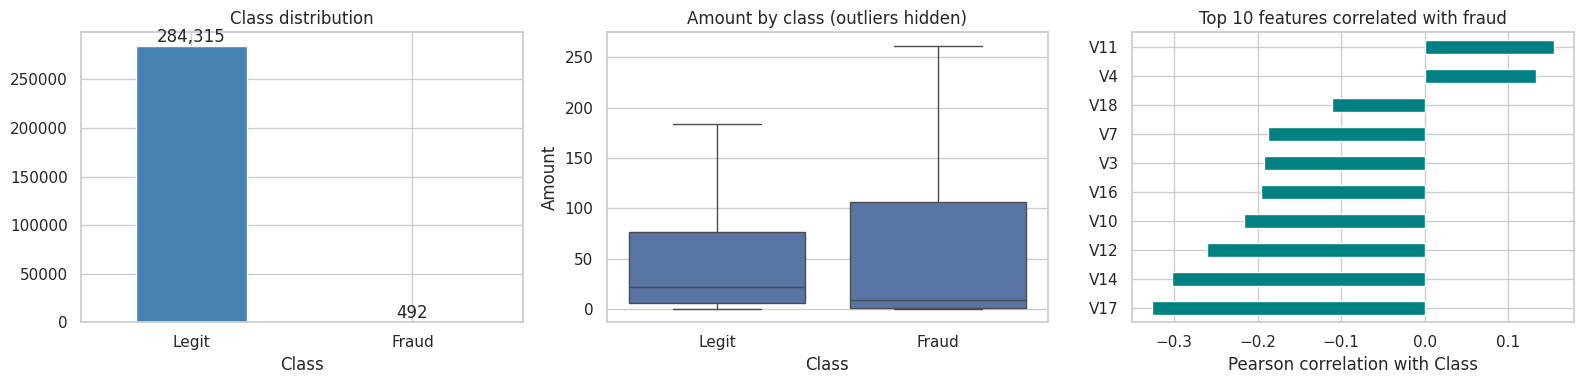

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df["Class"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "indianred"])
axes[0].set_title("Class distribution")
axes[0].set_xticklabels(["Legit", "Fraud"], rotation=0)
for i, v in enumerate(df["Class"].value_counts()):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

sns.boxplot(data=df, x="Class", y="Amount", ax=axes[1], showfliers=False)
axes[1].set_title("Amount by class (outliers hidden)")
axes[1].set_xticklabels(["Legit", "Fraud"])

feature_cols_all = [c for c in df.columns if c not in ("Class",)]
corr_with_class = df[feature_cols_all + ["Class"]].corr()["Class"].drop("Class")
top_corr = corr_with_class.abs().sort_values(ascending=False).head(10)
top_corr_signed = corr_with_class.loc[top_corr.index]
top_corr_signed.sort_values().plot(kind="barh", ax=axes[2], color="teal")
axes[2].set_title("Top 10 features correlated with fraud")
axes[2].set_xlabel("Pearson correlation with Class")

plt.tight_layout()
plt.savefig(FIGDIR / "eda_overview.png", dpi=150)
plt.show()

## 2. Feature preparation

`V1`–`V28` are already PCA-transformed. We scale `Time` and `Amount`, fitting
the scaler on train only.

In [ ]:
feature_cols = [c for c in train.columns if c != "Class"]
scaler = StandardScaler()

train_s, val_s, test_s = train.copy(), val.copy(), test.copy()
for col in ["Time", "Amount"]:
    train_s[col] = scaler.fit_transform(train[[col]])
    val_s[col] = scaler.transform(val[[col]])
    test_s[col] = scaler.transform(test[[col]])

X_train, y_train = train_s[feature_cols], train_s["Class"]
X_val, y_val = val_s[feature_cols], val_s["Class"]
X_test, y_test = test_s[feature_cols], test_s["Class"]

print(X_train.shape, X_val.shape, X_test.shape)

(199366, 30) (28480, 30) (56961, 30)


## 3. RQ3 — Imbalance-handling strategies

In [ ]:
def apply_resampling(X, y, strategy, seed):
    if strategy in ("none", "class_weight"):
        return X, y
    if strategy == "smote":
        return SMOTE(random_state=seed).fit_resample(X, y)
    if strategy == "adasyn":
        return ADASYN(random_state=seed).fit_resample(X, y)
    raise ValueError(strategy)

## 4. RQ1 — Models, training, and evaluation helpers

In [ ]:
def get_models(strategy, y_train_original, seed):
    # IMPORTANT: contamination and scale_pos_weight are always computed from
    # the ORIGINAL (pre-resampling) fraud rate, never from a resampled y.
    # Reason: Isolation Forest is unsupervised and never sees labels during
    # fit(), so feeding it SMOTE/ADASYN-resampled data would be methodologically
    # incoherent - and ADASYN in particular can overshoot exact 50/50 balance
    # slightly, which breaks sklearn's contamination constraint (0.0, 0.5].
    fraud_ratio = y_train_original.mean()
    contamination = min(max(fraud_ratio, 1e-4), 0.5)  # safe clip either way
    scale_pos_weight = (1 - fraud_ratio) / fraud_ratio if fraud_ratio > 0 else 1
    class_weight = "balanced" if strategy == "class_weight" else None
    xgb_spw = scale_pos_weight if strategy == "class_weight" else 1

    return {
        "IsolationForest": IsolationForest(
            n_estimators=200, contamination=contamination,
            random_state=seed, n_jobs=-1,
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300, class_weight=class_weight,
            random_state=seed, n_jobs=-1,
        ),
        "XGBoost": xgb.XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            scale_pos_weight=xgb_spw, eval_metric="aucpr",
            random_state=seed, n_jobs=-1,
        ),
    }


def fit_predict(name, model, X_tr, y_tr, X_te):
    t0 = time.time()
    if name == "IsolationForest":
        model.fit(X_tr)
    else:
        model.fit(X_tr, y_tr)
    train_time_s = time.time() - t0

    t1 = time.time()
    if name == "IsolationForest":
        raw = model.predict(X_te)
        y_pred = np.where(raw == -1, 1, 0)
        y_score = -model.score_samples(X_te)
    else:
        y_pred = model.predict(X_te)
        y_score = model.predict_proba(X_te)[:, 1]
    latency_ms = (time.time() - t1) * 1000 / len(X_te)

    return y_pred, y_score, train_time_s, latency_ms


def evaluate(y_true, y_pred, y_score):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_score),
        "roc_auc": roc_auc_score(y_true, y_score),
    }


## 5. Run the full experiment grid: models × imbalance strategies × repeated seeds

This is the core experiment. With `N_RUNS = 3` you get 3 × 4 × 3 = 36 model
fits — enough to report **mean ± std** per configuration rather than a single
point estimate, which is what a thesis committee will expect to see.

The best model + strategy of each run's *last* seed is kept for the
diagnostic plots afterward (ROC/PR curves, feature importance, confusion
matrices, threshold analysis).

In [ ]:
all_results = []
last_run_artifacts = {}  # (model, strategy) -> dict with y_pred, y_score, fitted_model

for strategy in STRATEGIES:
    print(f"\n=== Strategy: {strategy} ===")
    for seed in RANDOM_SEEDS:
        # Resampled data is used for RandomForest/XGBoost only.
        X_res, y_res = apply_resampling(X_train, y_train, strategy, seed)
        # get_models always uses the ORIGINAL y_train to size contamination /
        # scale_pos_weight - see the note in the helpers cell above.
        models = get_models(strategy, y_train, seed)

        for name, model in models.items():
            if name == "IsolationForest":
                # Unsupervised: always fit on the natural, un-resampled
                # distribution - resampling doesn't apply to it conceptually.
                fit_X, fit_y = X_train, y_train
            else:
                fit_X, fit_y = X_res, y_res

            y_pred, y_score, train_time_s, latency_ms = fit_predict(name, model, fit_X, fit_y, X_test)
            metrics = evaluate(y_test, y_pred, y_score)
            metrics.update({
                "model": name,
                "imbalance_strategy": strategy,
                "seed": seed,
                "train_time_s": train_time_s,
                "latency_ms_per_sample": latency_ms,
                "train_size": len(fit_X),
            })
            all_results.append(metrics)

            last_run_artifacts[(name, strategy)] = {
                "y_pred": y_pred, "y_score": y_score, "model": model,
            }

        print(f"  seed {seed} done")

raw_results_df = pd.DataFrame(all_results)
raw_results_df.to_csv(OUTDIR / "raw_results_all_seeds.csv", index=False)
print(f"\n{len(raw_results_df)} total runs completed.")



=== Strategy: none ===
  seed 0 done
  seed 1 done
  seed 2 done

=== Strategy: smote ===
  seed 0 done
  seed 1 done
  seed 2 done

=== Strategy: adasyn ===
  seed 0 done
  seed 1 done
  seed 2 done

=== Strategy: class_weight ===
  seed 0 done
  seed 1 done
  seed 2 done

36 total runs completed.


## 5.1 Aggregate across seeds — mean ± std per configuration

This table is the one to paste into Chapter 4. It reports mean and standard
deviation across the `N_RUNS` seeds, which is much stronger evidence than a
single run.

In [ ]:
metric_cols = ["precision", "recall", "f1", "pr_auc", "roc_auc",
               "train_time_s", "latency_ms_per_sample"]

agg = (raw_results_df
       .groupby(["model", "imbalance_strategy"])[metric_cols]
       .agg(["mean", "std"]))
agg.columns = [f"{m}_{s}" for m, s in agg.columns]
agg = agg.reset_index().round(4)

agg.to_csv(OUTDIR / "rq1_rq3_aggregated_results.csv", index=False)
agg

,model,imbalance_strategy,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,train_time_s_mean,train_time_s_std,latency_ms_per_sample_mean,latency_ms_per_sample_std
0,IsolationForest,adasyn,0.0141,0.0244,0.0133,0.0231,0.0137,0.0237,0.0452,0.0084,0.9493,0.0100,2.9924,0.1998,0.0238,0.0056
1,IsolationForest,class_weight,0.0141,0.0244,0.0133,0.0231,0.0137,0.0237,0.0452,0.0084,0.9493,0.0100,3.4853,0.6172,0.0222,0.0027
2,IsolationForest,none,0.0141,0.0244,0.0133,0.0231,0.0137,0.0237,0.0452,0.0084,0.9493,0.0100,3.9267,0.4868,0.0327,0.0102
3,IsolationForest,smote,0.0141,0.0244,0.0133,0.0231,0.0137,0.0237,0.0452,0.0084,0.9493,0.0100,3.7914,0.5699,0.0239,0.0052
4,RandomForest,adasyn,0.9584,0.0096,0.7156,0.0077,0.8193,0.0046,0.8226,0.0037,0.9640,0.0028,1315.8952,5.9635,0.0353,0.0011
5,RandomForest,class_weight,1.0000,0.0000,0.6178,0.0077,0.7637,0.0059,0.8135,0.0047,0.9521,0.0040,356.7439,0.7464,0.0326,0.0114
6,RandomForest,none,0.9806,0.0002,0.6756,0.0077,0.8000,0.0055,0.7914,0.0028,0.9569,0.0038,658.1232,10.5017,0.0510,0.0140
7,RandomForest,smote,0.9372,0.0096,0.7289,0.0077,0.8200,0.0076,0.8164,0.0021,0.9646,0.0026,1160.1756,8.5975,0.0551,0.0220
8,XGBoost,adasyn,0.7601,0.0090,0.7600,0.0133,0.7600,0.0072,0.7797,0.0048,0.9742,0.0029,21.1670,0.8802,0.0176,0.0050
9,XGBoost,class_weight,0.8730,0.0000,0.7333,0.0000,0.7971,0.0000,0.7875,0.0000,0.9851,0.0000,11.1151,1.3291,0.0117,0.0002


## 5.2 Heatmaps — mean recall / F1 / PR-AUC across all 12 configurations

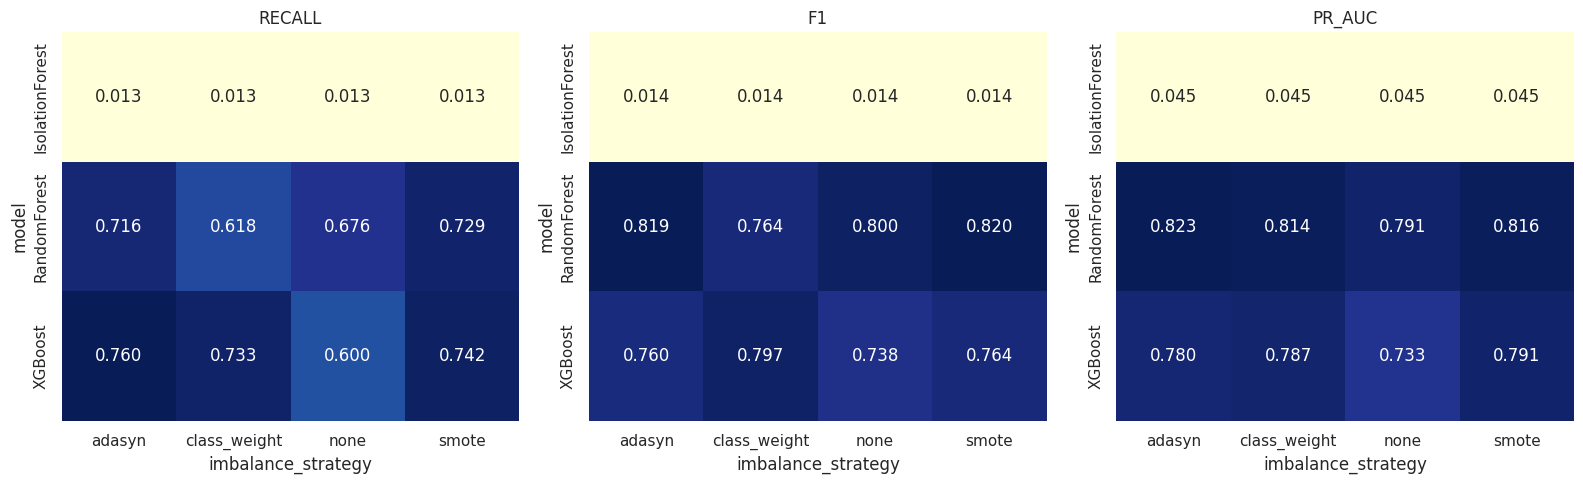

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ["recall_mean", "f1_mean", "pr_auc_mean"]):
    pivot = agg.pivot(index="model", columns="imbalance_strategy", values=metric)
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax, cbar=False)
    ax.set_title(metric.replace("_mean", "").upper())

plt.tight_layout()
plt.savefig(FIGDIR / "rq1_rq3_heatmaps.png", dpi=150)
plt.show()

## 6. ROC and Precision-Recall curves

PR curves matter more than ROC here given how imbalanced the data is — ROC
can look deceptively good even for a weak model when the negative class
dominates. Curves are shown for the last seed's fit under the "none" strategy,
so the three algorithm families can be compared directly without resampling
as a confound.

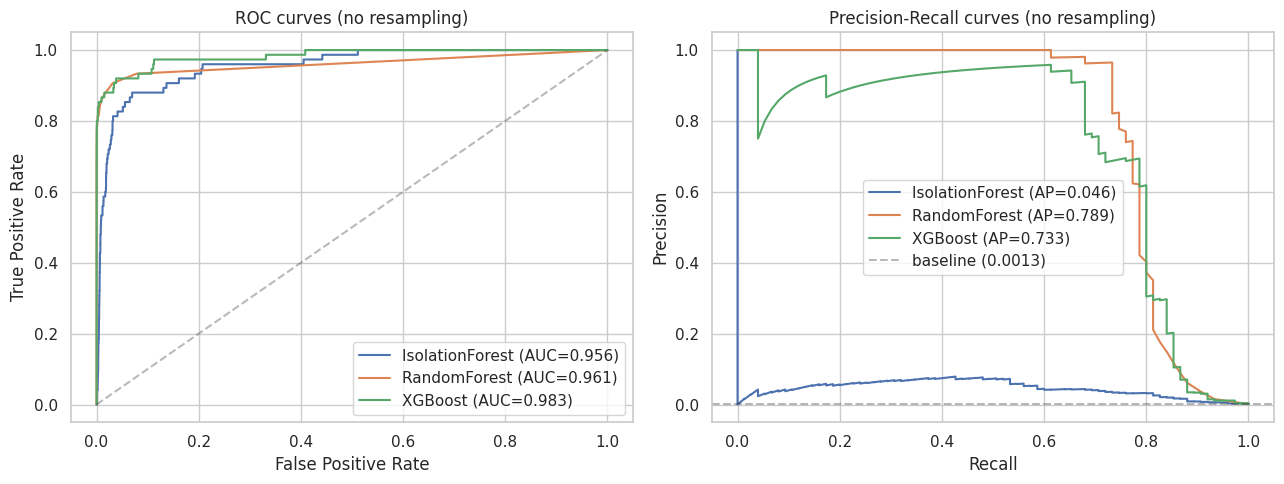

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name in ["IsolationForest", "RandomForest", "XGBoost"]:
    art = last_run_artifacts[(name, "none")]
    fpr, tpr, _ = roc_curve(y_test, art["y_score"])
    prec, rec, _ = precision_recall_curve(y_test, art["y_score"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, art['y_score']):.3f})")
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, art['y_score']):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curves (no resampling)"); axes[0].legend()

baseline_rate = y_test.mean()
axes[1].axhline(baseline_rate, color="k", linestyle="--", alpha=0.3, label=f"baseline ({baseline_rate:.4f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves (no resampling)"); axes[1].legend()

plt.tight_layout()
plt.savefig(FIGDIR / "roc_pr_curves.png", dpi=150)
plt.show()

## 7. Feature importance — Random Forest and XGBoost

Ties directly into RQ3 (which engineered/available features matter most).
Isolation Forest doesn't expose comparable importances, so it's excluded here.

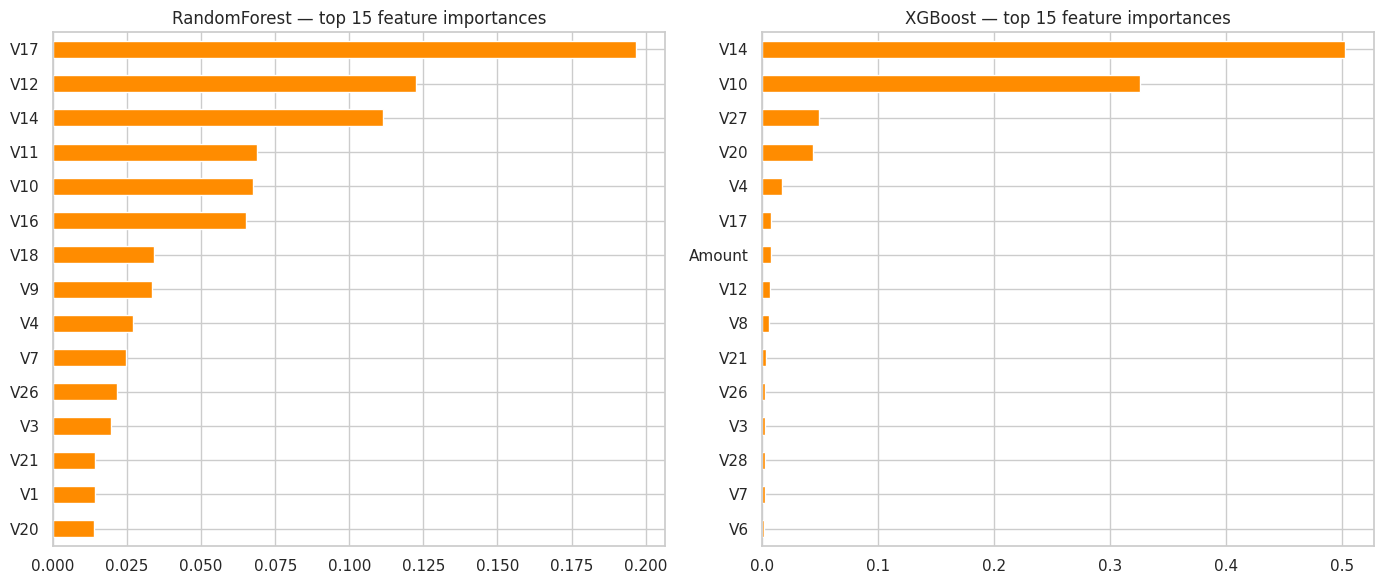

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, name in zip(axes, ["RandomForest", "XGBoost"]):
    model = last_run_artifacts[(name, "none")]["model"]
    importances = pd.Series(model.feature_importances_, index=feature_cols)
    top15 = importances.sort_values(ascending=False).head(15)
    top15.sort_values().plot(kind="barh", ax=ax, color="darkorange")
    ax.set_title(f"{name} — top 15 feature importances")

plt.tight_layout()
plt.savefig(FIGDIR / "feature_importance.png", dpi=150)
plt.show()

## 8. Threshold analysis — precision/recall trade-off

The default classification threshold (0.5) is rarely the right operating
point for a fraud system. This plot shows how precision, recall, and F1 move
as the threshold changes for the best-performing model (by F1, no resampling),
so you can justify a specific operating point in Chapter 4/5 instead of just
using the sklearn default.

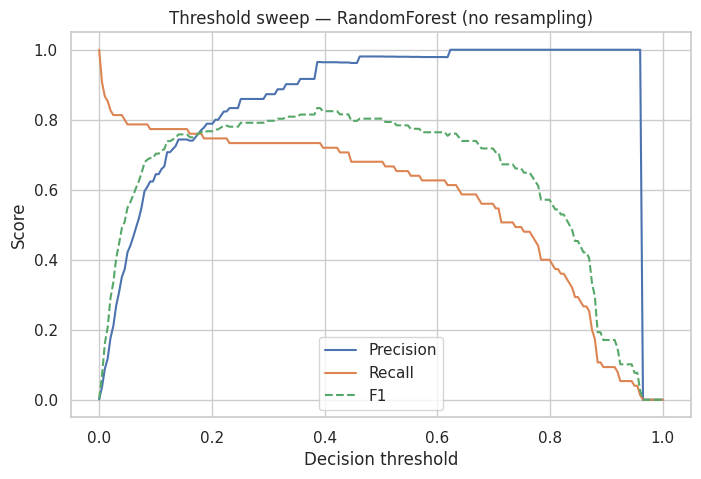

Best threshold by F1: 0.3869 (precision=0.965, recall=0.733, f1=0.833)


In [ ]:
best_name = agg.loc[agg["f1_mean"].idxmax(), "model"]
art = last_run_artifacts[(best_name, "none")]
y_score = art["y_score"]

thresholds = np.linspace(y_score.min(), y_score.max(), 200) if best_name == "IsolationForest" else np.linspace(0, 1, 200)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    pred_t = (y_score >= t).astype(int)
    precisions.append(precision_score(y_test, pred_t, zero_division=0))
    recalls.append(recall_score(y_test, pred_t, zero_division=0))
    f1s.append(f1_score(y_test, pred_t, zero_division=0))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1", linestyle="--")
plt.xlabel("Decision threshold"); plt.ylabel("Score")
plt.title(f"Threshold sweep — {best_name} (no resampling)")
plt.legend()
plt.savefig(FIGDIR / "threshold_analysis.png", dpi=150)
plt.show()

best_f1_idx = int(np.argmax(f1s))
print(f"Best threshold by F1: {thresholds[best_f1_idx]:.4f} "
      f"(precision={precisions[best_f1_idx]:.3f}, recall={recalls[best_f1_idx]:.3f}, f1={f1s[best_f1_idx]:.3f})")

## 9. Confusion matrices — all three models side by side (no resampling)

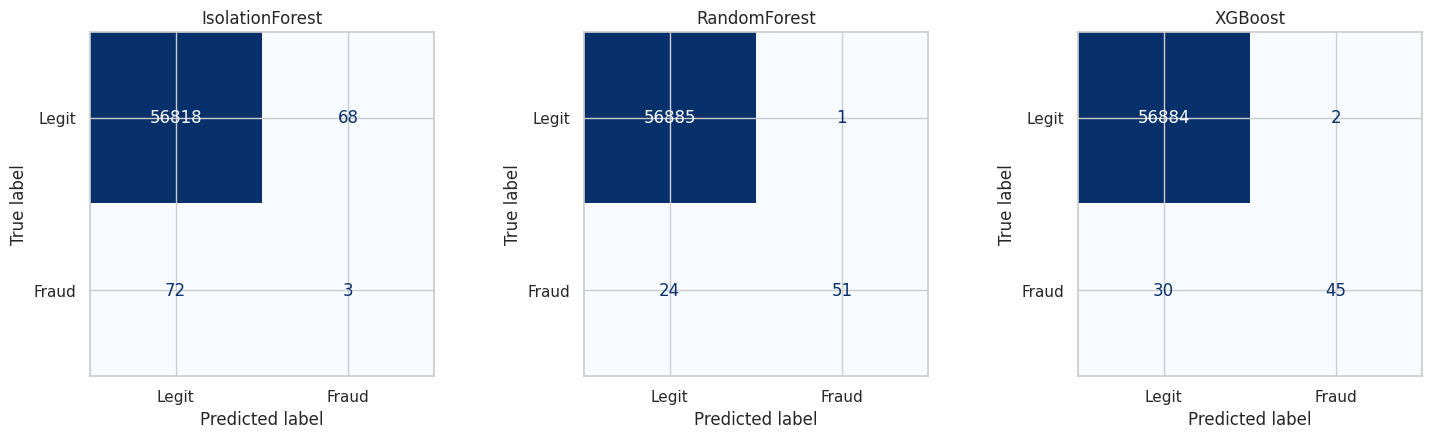

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, name in zip(axes, ["IsolationForest", "RandomForest", "XGBoost"]):
    art = last_run_artifacts[(name, "none")]
    cm = confusion_matrix(y_test, art["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"])
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig(FIGDIR / "confusion_matrices_all_models.png", dpi=150)
plt.show()

## 9.1 Full classification report — best configuration

In [ ]:
best_row = agg.loc[agg["f1_mean"].idxmax()]
best_name, best_strategy = best_row["model"], best_row["imbalance_strategy"]
art = last_run_artifacts[(best_name, best_strategy)]

print(f"Best configuration: {best_name} + {best_strategy}\n")
print(classification_report(y_test, art["y_pred"], target_names=["Legit", "Fraud"], digits=4))

Best configuration: RandomForest + smote

              precision    recall  f1-score   support

       Legit     0.9996    0.9999    0.9998     56886
       Fraud     0.9483    0.7333    0.8271        75

    accuracy                         0.9996     56961
   macro avg     0.9740    0.8666    0.9134     56961
weighted avg     0.9996    0.9996    0.9996     56961



## 10. Training time vs inference latency (RQ4)

Training time matters for how often you can afford to retrain as fraud
patterns drift; inference latency matters for whether the model fits a
real-time scoring budget.

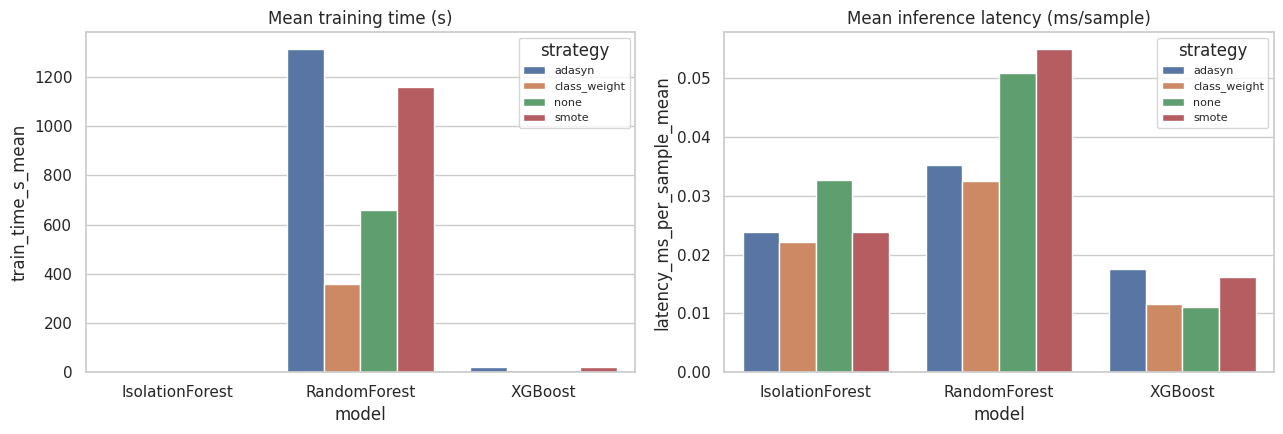

In [ ]:
time_df = agg[["model", "imbalance_strategy", "train_time_s_mean", "latency_ms_per_sample_mean"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=time_df, x="model", y="train_time_s_mean", hue="imbalance_strategy", ax=axes[0])
axes[0].set_title("Mean training time (s)")
axes[0].legend(title="strategy", fontsize=8)

sns.barplot(data=time_df, x="model", y="latency_ms_per_sample_mean", hue="imbalance_strategy", ax=axes[1])
axes[1].set_title("Mean inference latency (ms/sample)")
axes[1].legend(title="strategy", fontsize=8)

plt.tight_layout()
plt.savefig(FIGDIR / "rq4_time_and_latency.png", dpi=150)
plt.show()

## 11. Save everything for Chapter 4

- `raw_results_all_seeds.csv` — every individual run (for appendix / supplementary tables)
- `rq1_rq3_aggregated_results.csv` — mean ± std per configuration (the main table)
- `figures/` — every plot generated above, saved as 150 dpi PNGs
- `models/` — the best model, pickled, so it can be reloaded later for SHAP work (RQ2) without retraining

In [ ]:
joblib.dump(art["model"], MODELDIR / f"best_model_{best_name}_{best_strategy}.joblib")

print("Saved:")
print(f"  {OUTDIR / 'raw_results_all_seeds.csv'}")
print(f"  {OUTDIR / 'rq1_rq3_aggregated_results.csv'}")
print(f"  {FIGDIR} (7 figures)")
print(f"  {MODELDIR / f'best_model_{best_name}_{best_strategy}.joblib'}")

print(f"\n=== Best overall configuration: {best_name} + {best_strategy} ===")
print(best_row[["precision_mean", "recall_mean", "f1_mean", "pr_auc_mean", "roc_auc_mean"]])

Saved:
  /content/drive/MyDrive/Bicocca/Thesis code/results/credit_card/raw_results_all_seeds.csv
  /content/drive/MyDrive/Bicocca/Thesis code/results/credit_card/rq1_rq3_aggregated_results.csv
  /content/drive/MyDrive/Bicocca/Thesis code/results/credit_card/figures (7 figures)
  /content/drive/MyDrive/Bicocca/Thesis code/results/credit_card/models/best_model_RandomForest_smote.joblib

=== Best overall configuration: RandomForest + smote ===
precision_mean    0.9372
recall_mean       0.7289
f1_mean             0.82
pr_auc_mean       0.8164
roc_auc_mean      0.9646
Name: 7, dtype: object
